# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# **Load Datasets**

In [2]:
library_df = pd.read_csv("data/library_usage_data.csv")
study_df = pd.read_csv("data/study_area_usage_data.csv")

# **Saving All Plots**

In [3]:
import matplotlib.pyplot as plt
import os
from datetime import datetime

# Create output directory
output_dir = 'saved_plots'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Override plt.show() to auto-save before displaying
original_show = plt.show
plot_counter = 0

def save_and_show(*args, **kwargs):
    global plot_counter
    plot_counter += 1
    
    # Generate filename with timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"{output_dir}/plot_{plot_counter:03d}_{timestamp}.png"
    
    # Save current figure
    plt.savefig(filename, dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    print(f"✓ Saved: {filename}")
    
    # Show the plot
    original_show(*args, **kwargs)

# Replace plt.show with our custom function
plt.show = save_and_show

print("Auto-save enabled! All plots will be saved to 'saved_plots/' folder.")

Auto-save enabled! All plots will be saved to 'saved_plots/' folder.


# **Explore the Data**

## **Check first rows**

In [4]:
library_df.head()

,Student ID,Department,Programme,Book ID,Book Category,Issue Date,Return Date,Entry Time,Exit Time
0,MEP22235,Mechanical Engineering,Ph.D. in Mechanical Engineering,B00317,Physics,2024-05-07,2024-05-11,11:46,14:46
1,MEB20014,Mechanical Engineering,B. Tech. in Mechanical Engineering,B00133,Physics,2024-10-22,2024-11-17,16:17,18:35
2,ECS24187,Electronics & Communication Engineering,M. Tech. in Semiconductor Technology,B00054,Computer Science,2026-03-07,Not Returned,13:01,17:00
3,HIP22120,Hindi,Ph.D. in Hindi,B00381,Fiction,2025-05-08,Not Returned,09:38,13:46
4,BAM21161,Business Administration,Master of Business Administration,B00298,Management,2025-12-03,2025-12-05,09:12,11:21


In [5]:
study_df.head()

,Date,Roll No,Department,Programme,Entry Time,Exit Time
0,2025-10-23,APP21028,Applied Sciences,Ph.D. in Applied Sciences,13:16,16:09
1,2024-06-18,EEP22174,Electrical Engineering,Ph.D. in Electrical Engineering,20:57,00:59
2,2025-01-07,BAT24164,Business Administration,Master of Tourism & Travel Management,21:46,23:00
3,2024-12-04,CHB20055,Chemical Sciences,Integrated B.Sc.B.Ed. (Chemistry Major),11:21,15:16
4,2026-04-03,EDT25169,Electronics & Communication Engineering,M. Tech. in Electronics Design & Technology,20:34,21:13


## **Check Columns**

In [6]:
library_df.columns

Index(['Student ID', 'Department', 'Programme', 'Book ID', 'Book Category',
       'Issue Date', 'Return Date', 'Entry Time', 'Exit Time'],
      dtype='str')

## **Check Missing Values**

In [7]:
library_df.isnull().sum()

Student ID       0
Department       0
Programme        0
Book ID          0
Book Category    0
Issue Date       0
Return Date      0
Entry Time       0
Exit Time        0
dtype: int64

## **Check Data Types**

In [8]:
library_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Student ID     30000 non-null  str  
 1   Department     30000 non-null  str  
 2   Programme      30000 non-null  str  
 3   Book ID        30000 non-null  str  
 4   Book Category  30000 non-null  str  
 5   Issue Date     30000 non-null  str  
 6   Return Date    30000 non-null  str  
 7   Entry Time     30000 non-null  str  
 8   Exit Time      30000 non-null  str  
dtypes: str(9)
memory usage: 4.9 MB


# **Data Cleaning**

## **Convert date columns**

In [9]:
# Create a flag for not returned books
library_df['Not Returned'] = library_df['Return Date'] == 'Not Returned'

# Then convert dates, setting "Not Returned" to NaT
library_df['Return Date'] = pd.to_datetime(library_df['Return Date'], errors='coerce')

## **Remove duplicates**

In [10]:
library_df.drop_duplicates(inplace=True)

# **Feature Engineering**

New analytical features are created from the existing raw data to enable deeper analysis.

Examples:
- Borrow Duration
- Study Duration
- Monthly Usage Trends

These derived features help identify student behavior patterns and library utilization trends.

## **Borrow Duration Analysis**

Borrow duration is calculated as the difference between the return date and issue date.

This helps analyze:
- Average borrowing duration
- Long-term resource usage
- Department-wise borrowing behavior

In [11]:
# Convert date columns to datetime

library_df['Issue Date'] = pd.to_datetime(library_df['Issue Date'])
library_df['Return Date'] = pd.to_datetime(library_df['Return Date'])

# Create borrow duration column

library_df['Borrow_Days'] = (
    library_df['Return Date']
    - library_df['Issue Date']
).dt.days

# Display result

library_df[['Issue Date', 'Return Date', 'Borrow_Days']].head()

,Issue Date,Return Date,Borrow_Days
0,2024-05-07,2024-05-11,4.0
1,2024-10-22,2024-11-17,26.0
2,2026-03-07,NaT,NaN
3,2025-05-08,NaT,NaN
4,2025-12-03,2025-12-05,2.0


## **Study Duration Analysis**

Study duration is calculated using entry and exit times.

This helps identify:
- Average study hours
- Student engagement
- Department-wise study patterns

In [12]:
# Convert entry and exit time columns

study_df['Entry Time'] = pd.to_datetime(study_df['Entry Time'])
study_df['Exit Time'] = pd.to_datetime(study_df['Exit Time'])

# Create study duration column in hours

study_df['Study_Duration_Hours'] = (
    study_df['Exit Time']
    - study_df['Entry Time']
).dt.total_seconds() / 3600

# Display result

study_df[['Entry Time', 'Exit Time', 'Study_Duration_Hours']].head()

C:\Users\AkashDeep\AppData\Local\Temp\ipykernel_9120\1872380552.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  study_df['Entry Time'] = pd.to_datetime(study_df['Entry Time'])
C:\Users\AkashDeep\AppData\Local\Temp\ipykernel_9120\1872380552.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  study_df['Exit Time'] = pd.to_datetime(study_df['Exit Time'])


,Entry Time,Exit Time,Study_Duration_Hours
0,2026-05-19 13:16:00,2026-05-19 16:09:00,2.883333
1,2026-05-19 20:57:00,2026-05-19 00:59:00,-19.966667
2,2026-05-19 21:46:00,2026-05-19 23:00:00,1.233333
3,2026-05-19 11:21:00,2026-05-19 15:16:00,3.916667
4,2026-05-19 20:34:00,2026-05-19 21:13:00,0.650000


## **Monthly Trend Feature**

A month column is extracted from the issue date to analyze monthly usage trends and seasonal patterns.

In [13]:
# Extract month from issue date

library_df['Month'] = library_df['Issue Date'].dt.month

# Extract year

library_df['Year'] = library_df['Issue Date'].dt.year

# Display result

library_df[['Issue Date', 'Month', 'Year']].head()

,Issue Date,Month,Year
0,2024-05-07,5,2024
1,2024-10-22,10,2024
2,2026-03-07,3,2026
3,2025-05-08,5,2025
4,2025-12-03,12,2025


## **Day-wise Usage Analysis**

Day names are taken out to look at patterns in library activity over the course of a week.

In [14]:
# Create weekday column

library_df['Day_Name'] = library_df['Issue Date'].dt.day_name()

# Display result

library_df[['Issue Date', 'Day_Name']].head()

,Issue Date,Day_Name
0,2024-05-07,Tuesday
1,2024-10-22,Tuesday
2,2026-03-07,Saturday
3,2025-05-08,Thursday
4,2025-12-03,Wednesday


## **Average Study Duration by Department**

This study looks at how many hours of study each department has on average.

In [15]:
avg_study = study_df.groupby('Department')[
    'Study_Duration_Hours'
].mean().sort_values(ascending=False)

avg_study

Department
Energy                                    -1.461533
Multidisciplinary Research                -1.480222
Assamese                                  -1.489136
Sociology                                 -1.651843
Electrical Engineering                    -1.699089
Environmental Sciences                    -1.722921
Linguistics and Language Technology       -1.861635
Civil Engineering                         -1.891022
Molecular Biology & Biotechnology         -1.905753
Chemical Sciences                         -1.923051
Mathematical Sciences                     -2.000582
Physics                                   -2.013308
Cultural Studies                          -2.043849
Education                                 -2.048339
Mass Communication & Journalism           -2.061219
Business Administration                   -2.108564
Food Engineering & Technology             -2.148976
Law                                       -2.154490
Social Work                               -2.160918
C

## **Average Study Duration by Department**

This analysis compares average study hours among different departments.

In [16]:
dept_usage = library_df['Department'].value_counts()

dept_usage

Department
Business Administration                    2098
Education                                  2012
Electronics & Communication Engineering    1936
Chemical Sciences                          1745
Computer Science & Engineering             1729
Mechanical Engineering                     1570
Molecular Biology & Biotechnology          1365
Physics                                    1268
Mathematical Sciences                      1231
Civil Engineering                          1103
Design                                     1091
English                                    1070
Cultural Studies                           1015
Assamese                                    977
Hindi                                       971
Women Study                                 917
Law                                         826
Food Engineering & Technology               819
Sociology                                   806
Environmental Sciences                      779
Linguistics and Language Tech

## **Book Category Analysis**

This analysis identifies the most frequently borrowed book categories.

In [17]:
book_categories = library_df['Book Category'].value_counts()

book_categories

Book Category
Humanities          9224
Chemistry           3757
Physics             3750
Mathematics         3622
Computer Science    2880
Management          2411
Fiction             1558
Mechanical          1416
Electronics         1382
Name: count, dtype: int64

## **Monthly Library Usage Trend**

Monthly usage patterns are analyzed to identify seasonal and examination-period activity spikes.

In [18]:
monthly_usage = library_df.groupby('Month').size()

monthly_usage

Month
1     2736
2     2477
3     2791
4     2639
5     2083
6     1880
7     1976
8     2714
9     2645
10    2689
11    2701
12    2669
dtype: int64

## **Peak Hour Analysis**

Entry hours are analyzed to identify peak library occupancy times.

In [19]:
# Extract entry hour

study_df['Entry_Hour'] = study_df['Entry Time'].dt.hour

# Count hourly entries

peak_hours = study_df['Entry_Hour'].value_counts().sort_index()

peak_hours

Entry_Hour
0     1627
1     1683
2      843
9     1735
10    1693
11    1696
12    1674
13    1804
14    1752
15    1751
16    1742
17    1707
18    1691
19    1721
20    1705
21    1729
22    1775
23    1672
Name: count, dtype: int64

## **Correlation Analysis**

Correlation analysis helps identify relationships between numerical variables in the dataset.

In [20]:
# Step 1: Create numeric features
library_df['Entry_Hour'] = pd.to_datetime(library_df['Entry Time']).dt.hour
library_df['Exit_Hour'] = pd.to_datetime(library_df['Exit Time']).dt.hour
library_df['Library_Hours'] = (
    pd.to_datetime(library_df['Exit Time']) - pd.to_datetime(library_df['Entry Time'])
).dt.total_seconds() / 3600
library_df['Issue_DayOfWeek'] = pd.to_datetime(library_df['Issue Date']).dt.dayofweek
library_df['Issue_DayOfMonth'] = pd.to_datetime(library_df['Issue Date']).dt.day

# Step 2: Select numeric columns
numeric_columns = [
    'Borrow_Days',
    'Month',
    'Year',
    'Entry_Hour',
    'Exit_Hour',
    'Library_Hours',
    'Issue_DayOfWeek',
    'Issue_DayOfMonth'
]

# Step 3: Keep only existing columns
available_columns = [col for col in numeric_columns if col in library_df.columns]

# Step 4: Remove rows with NaN (books not returned)
corr_data = library_df[available_columns].dropna()

print(f"Rows before dropping NaN: {len(library_df)}")
print(f"Rows after dropping NaN: {len(corr_data)}")
print(f"Columns in correlation: {available_columns}")

# Step 5: Calculate correlation matrix
correlation_matrix = corr_data.corr()

# Step 6: Display styled correlation matrix
correlation_matrix.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)

C:\Users\AkashDeep\AppData\Local\Temp\ipykernel_9120\3203191664.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  library_df['Entry_Hour'] = pd.to_datetime(library_df['Entry Time']).dt.hour
C:\Users\AkashDeep\AppData\Local\Temp\ipykernel_9120\3203191664.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  library_df['Exit_Hour'] = pd.to_datetime(library_df['Exit Time']).dt.hour
C:\Users\AkashDeep\AppData\Local\Temp\ipykernel_9120\3203191664.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(library_df['Exit Time']) - pd.to_datetime(library_df['Entry Time'])

Rows before dropping NaN: 30000
Rows after dropping NaN: 26277
Columns in correlation: ['Borrow_Days', 'Month', 'Year', 'Entry_Hour', 'Exit_Hour', 'Library_Hours', 'Issue_DayOfWeek', 'Issue_DayOfMonth']


,Borrow_Days,Month,Year,Entry_Hour,Exit_Hour,Library_Hours,Issue_DayOfWeek,Issue_DayOfMonth
Borrow_Days,1.000000,-0.003610,-0.018792,-0.010793,-0.012404,0.000994,-0.003229,-0.011252
Month,-0.003610,1.000000,-0.580990,0.005684,0.004932,-0.002404,-0.008277,0.024009
Year,-0.018792,-0.580990,1.000000,-0.002704,-0.002184,0.002968,0.001336,-0.046638
Entry_Hour,-0.010793,0.005684,-0.002704,1.000000,0.829113,-0.434111,-0.060571,-0.001887
Exit_Hour,-0.012404,0.004932,-0.002184,0.829113,1.000000,0.121718,-0.091711,-0.000003
Library_Hours,0.000994,-0.002404,0.002968,-0.434111,0.121718,1.000000,-0.089327,0.004316
Issue_DayOfWeek,-0.003229,-0.008277,0.001336,-0.060571,-0.091711,-0.089327,1.000000,0.013906
Issue_DayOfMonth,-0.011252,0.024009,-0.046638,-0.001887,-0.000003,0.004316,0.013906,1.000000


## **Exporting Processed Dataset**

The cleaned and processed datasets are exported for dashboard development and further visualization.

In [21]:
library_df.to_csv(
    "processed_library_data.csv",
    index=False
)

study_df.to_csv(
    "processed_study_data.csv",
    index=False
)

print("Processed datasets exported successfully.")

Processed datasets exported successfully.


# **Department-wise Library Usage Analysis**

This visualization compares library usage among different departments to identify the most active users of library resources.

✓ Saved: saved_plots/plot_001_20260519_233106.png


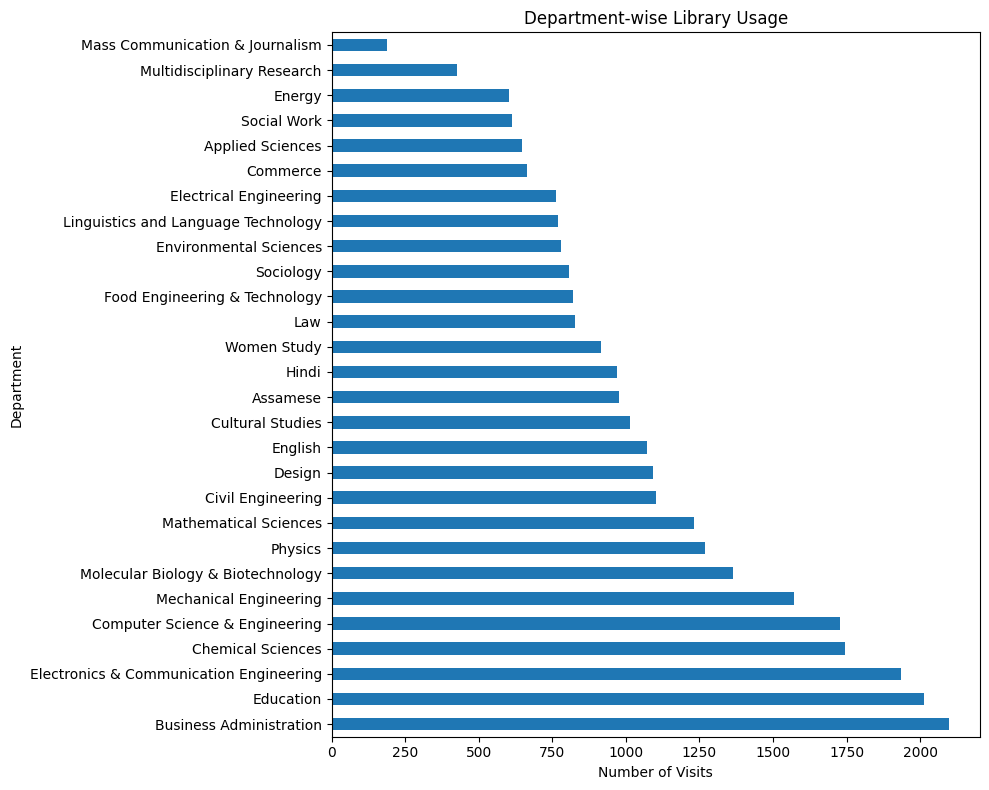

In [22]:
plt.figure(figsize=(10, 8))
dept_usage.plot(kind='barh')  # Horizontal bars
plt.title("Department-wise Library Usage")
plt.xlabel("Number of Visits")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

# **Most Popular Book Categories**

This analysis identifies the most frequently borrowed book categories in the central library.

✓ Saved: saved_plots/plot_002_20260519_233107.png


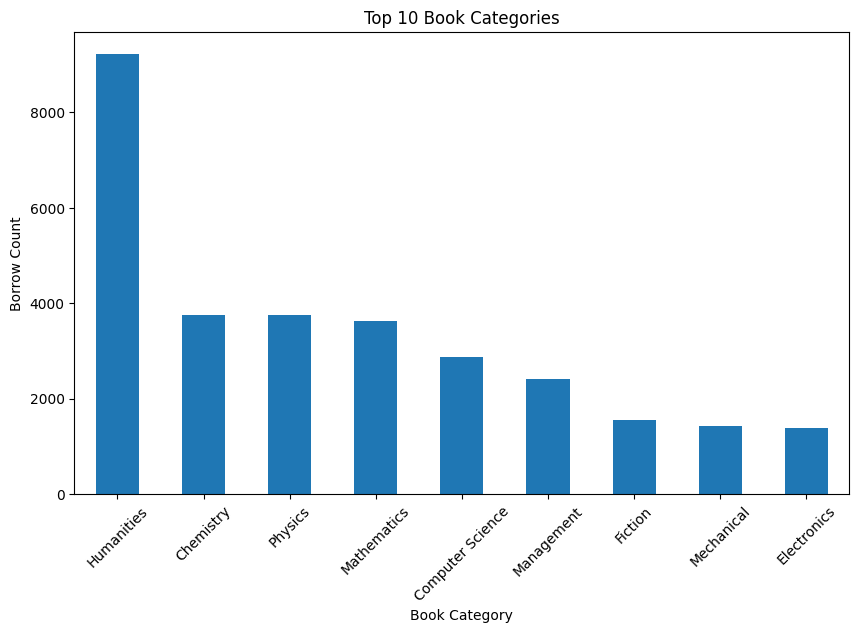

In [23]:
book_category = library_df['Book Category'].value_counts().head(10)

plt.figure(figsize=(10,6))

book_category.plot(kind='bar')

plt.title("Top 10 Book Categories")
plt.xlabel("Book Category")
plt.ylabel("Borrow Count")

plt.xticks(rotation=45)

plt.show()

# **Monthly Library Usage Trend**

Monthly usage trends help identify seasonal activity patterns and examination-period spikes.

✓ Saved: saved_plots/plot_003_20260519_233107.png


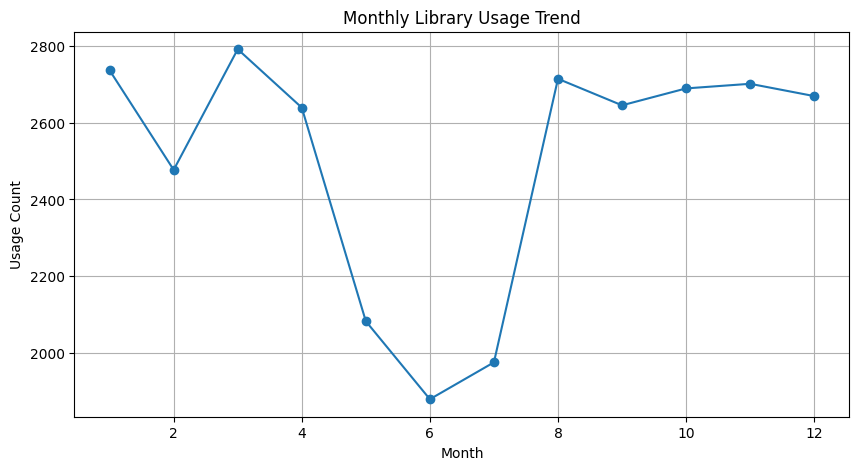

In [24]:
monthly_usage = library_df.groupby('Month').size()

plt.figure(figsize=(10,5))

monthly_usage.plot(
    kind='line',
    marker='o'
)

plt.title("Monthly Library Usage Trend")
plt.xlabel("Month")
plt.ylabel("Usage Count")

plt.grid(True)

plt.show()

# **Average Study Duration by Department**

This analysis compares the average study duration among departments.

✓ Saved: saved_plots/plot_004_20260519_233107.png


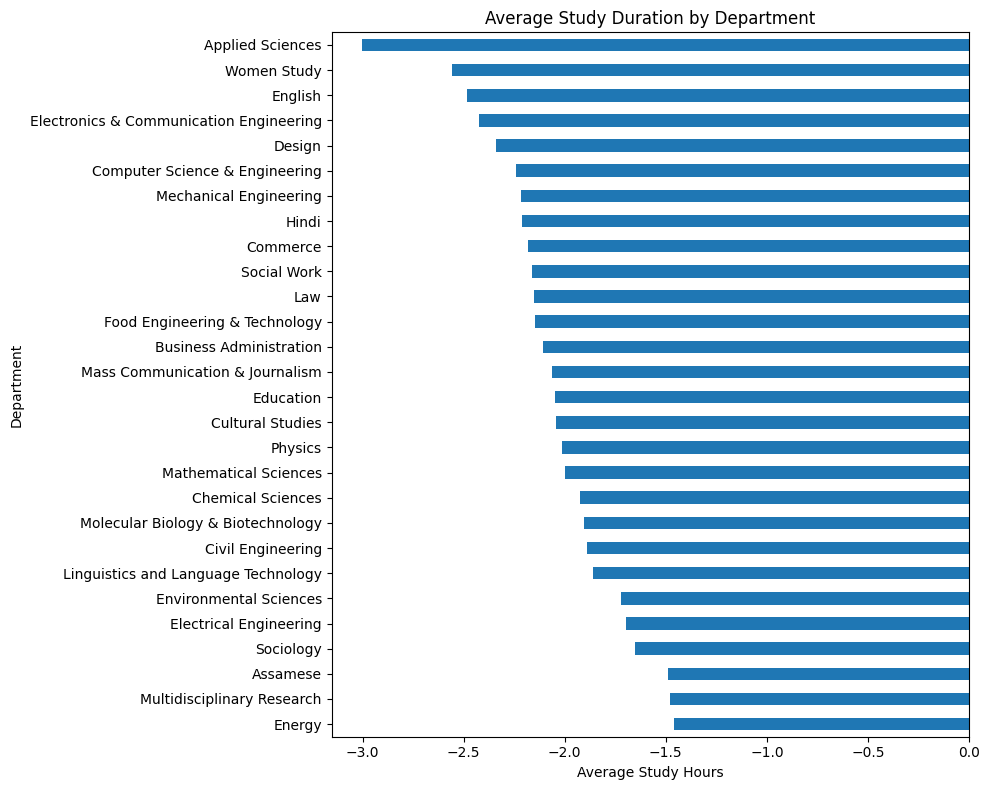

In [25]:
avg_study = study_df.groupby('Department')[
    'Study_Duration_Hours'
].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
avg_study.plot(kind='barh')  # Horizontal bars
plt.title("Average Study Duration by Department")
plt.xlabel("Average Study Hours")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

# **Peak Hour Library Occupancy**

This analysis identifies the busiest hours in the library based on student entry times.

✓ Saved: saved_plots/plot_005_20260519_233108.png


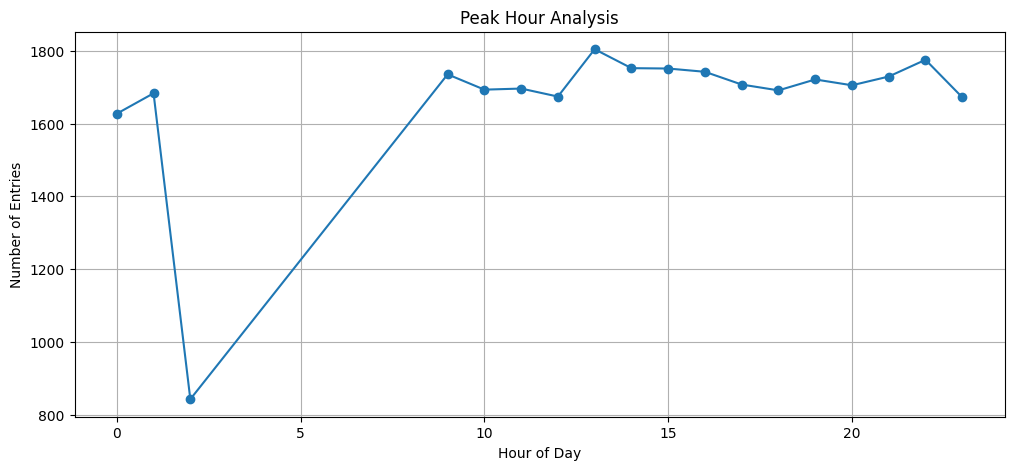

In [26]:
peak_hours = study_df['Entry_Hour'].value_counts().sort_index()

plt.figure(figsize=(12,5))

peak_hours.plot(kind='line', marker='o')

plt.title("Peak Hour Analysis")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Entries")

plt.grid(True)

plt.show()

# **Borrow Duration Distribution**

This visualization shows how long books are typically borrowed before being returned.

✓ Saved: saved_plots/plot_006_20260519_233108.png


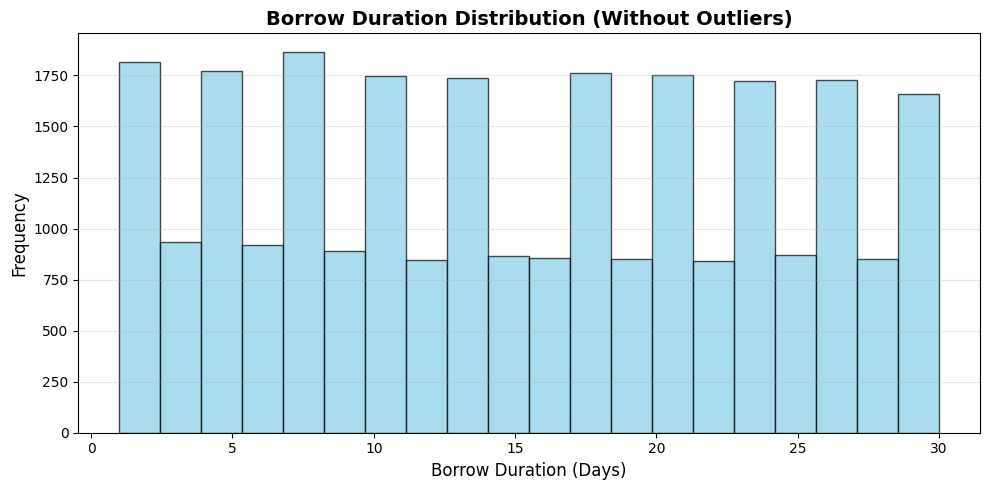

In [27]:
# Remove outliers using IQR method
Q1 = library_df['Borrow_Days'].quantile(0.25)
Q3 = library_df['Borrow_Days'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

filtered_data = library_df['Borrow_Days'][
    (library_df['Borrow_Days'] >= lower_bound) & 
    (library_df['Borrow_Days'] <= upper_bound)
]

plt.figure(figsize=(10, 5))
plt.hist(filtered_data, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Borrow Duration Distribution (Without Outliers)", fontsize=14, fontweight='bold')
plt.xlabel("Borrow Duration (Days)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# **Correlation Heatmap**

Correlation analysis is performed to identify relationships among numerical variables. A heatmap visually represents these correlations using color intensity, making it easy to identify strong and weak relationships at a glance.

C:\Users\AkashDeep\AppData\Local\Temp\ipykernel_9120\2305955369.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  library_df['Issue_Hour'] = pd.to_datetime(library_df['Entry Time']).dt.hour
C:\Users\AkashDeep\AppData\Local\Temp\ipykernel_9120\2305955369.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  library_df['Exit_Hour'] = pd.to_datetime(library_df['Exit Time']).dt.hour
C:\Users\AkashDeep\AppData\Local\Temp\ipykernel_9120\2305955369.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(library_df['Exit Time']) - pd.to_datetime(library_df['Entry Time'])

✓ Saved: saved_plots/plot_007_20260519_233109.png


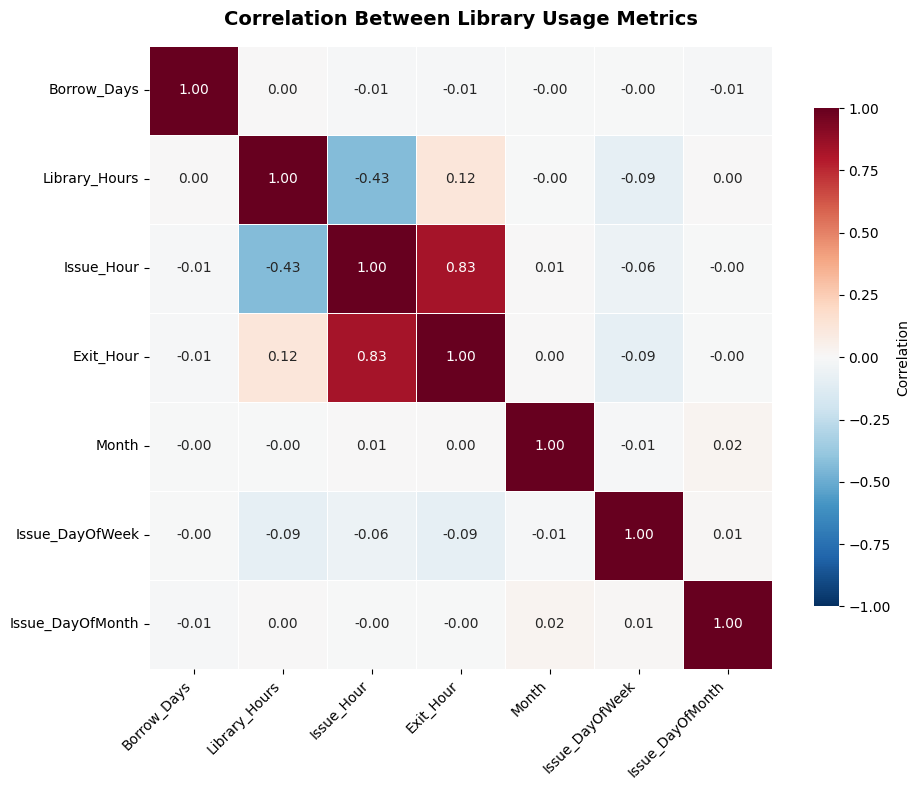


Key Correlations with Borrow_Days:
  Library_Hours: 0.001 (Weak Positive)
  Issue_DayOfWeek: -0.003 (Weak Negative)
  Month: -0.004 (Weak Negative)
  Issue_Hour: -0.011 (Weak Negative)
  Issue_DayOfMonth: -0.011 (Weak Negative)
  Exit_Hour: -0.012 (Weak Negative)


In [28]:
# Create key numeric features
library_df['Issue_Hour'] = pd.to_datetime(library_df['Entry Time']).dt.hour
library_df['Exit_Hour'] = pd.to_datetime(library_df['Exit Time']).dt.hour
library_df['Library_Hours'] = (
    pd.to_datetime(library_df['Exit Time']) - pd.to_datetime(library_df['Entry Time'])
).dt.total_seconds() / 3600
library_df['Issue_DayOfWeek'] = library_df['Issue Date'].dt.dayofweek
library_df['Issue_DayOfMonth'] = library_df['Issue Date'].dt.day

# Select only meaningful numeric features (excluding encoded categoricals)
numeric_cols = [
    'Borrow_Days',
    'Library_Hours',
    'Issue_Hour',
    'Exit_Hour',
    'Month',
    'Issue_DayOfWeek',
    'Issue_DayOfMonth'
]

# Remove NaN values
corr_data = library_df[numeric_cols].dropna()

# Calculate correlations
corr_matrix = corr_data.corr()

# Create annotated heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,                # Show correlation values
    fmt='.2f',                 # 2 decimal places
    cmap='RdBu_r',             # Red-Blue colormap (red=negative, blue=positive)
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"shrink": 0.8, "label": "Correlation"}
)

plt.title("Correlation Between Library Usage Metrics", 
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print correlation insights
print("\nKey Correlations with Borrow_Days:")
borrow_corr = corr_matrix['Borrow_Days'].sort_values(ascending=False)
for col, corr in borrow_corr.items():
    if col != 'Borrow_Days':
        strength = "Strong" if abs(corr) > 0.5 else "Moderate" if abs(corr) > 0.3 else "Weak"
        direction = "Positive" if corr > 0 else "Negative"
        print(f"  {col}: {corr:.3f} ({strength} {direction})")

In [29]:
library_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Student ID        30000 non-null  str           
 1   Department        30000 non-null  str           
 2   Programme         30000 non-null  str           
 3   Book ID           30000 non-null  str           
 4   Book Category     30000 non-null  str           
 5   Issue Date        30000 non-null  datetime64[us]
 6   Return Date       26277 non-null  datetime64[us]
 7   Entry Time        30000 non-null  str           
 8   Exit Time         30000 non-null  str           
 9   Not Returned      30000 non-null  bool          
 10  Borrow_Days       26277 non-null  float64       
 11  Month             30000 non-null  int32         
 12  Year              30000 non-null  int32         
 13  Day_Name          30000 non-null  str           
 14  Entry_Hour        30000 non-null 

# **Key Insights**

The visual analytics of the university central library datasets revealed several important behavioral and operational patterns:

- Business Administration recorded the highest library usage among all departments, followed closely by Education and Electronics & Communication Engineering.

- Engineering-related departments such as Computer Science & Engineering, Mechanical Engineering, and Electrical Engineering also showed consistently high library engagement, indicating strong academic resource utilization among technical disciplines.

- Humanities emerged as the most borrowed book category by a significant margin, suggesting broad interdisciplinary reading habits across students.

- Chemistry, Physics, and Mathematics were also among the highly borrowed categories, reflecting strong usage from science and engineering students.

- Monthly usage trends showed a noticeable decline during the mid-year period (May–July), followed by a sharp increase from August onwards, which may correspond to semester transitions and examination preparation periods.

- Peak hour analysis indicated that the library experiences maximum occupancy during afternoon and evening hours, particularly between 1 PM and 10 PM.

- Average study duration varied across departments, with Applied Sciences, Women Study, English, and Electronics & Communication Engineering students spending comparatively longer hours in study areas.

- Borrow duration distribution showed that most books were borrowed for short-to-medium durations, with the majority of borrowing periods falling within 1–30 days.

- Correlation analysis revealed a strong positive relationship between issue hour and exit hour, indicating that students entering the library later in the day also tend to stay later.

- Most other variables exhibited weak correlations, suggesting that library behavior patterns are influenced by multiple independent factors rather than a single dominant variable.

# **Conclusion**

This project successfully analyzed university central library usage and study-area occupancy patterns using data analytics and visualization techniques.

The analysis provided meaningful insights into:
- Department-wise library engagement
- Book borrowing behavior
- Study duration trends
- Time-based occupancy patterns
- Resource utilization across academic disciplines

The visualizations demonstrated that technical and professional departments make extensive use of library resources, while humanities-related book categories remain highly popular across the university community.

Temporal analysis revealed clear fluctuations in library activity throughout the academic year, with higher occupancy observed during active academic and examination periods.

The correlation analysis further highlighted relationships between entry and exit timing behaviors, offering deeper understanding of student study habits.

Overall, the project demonstrates how institutional data can be transformed into actionable insights using exploratory data analysis and interactive visualization methods.

The developed analytics framework can support:
- Better library resource planning
- Space utilization optimization
- Academic support services
- Student engagement monitoring
- Data-driven administrative decision-making